In [3]:
import pandas as pd
import os
import time
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
from tqdm import tqdm
from IPython.display import clear_output

# --- KONFIGURASI ---
BASE_NOISE_DIR = r'D:\waveform_data_noise'
CATALOG_PATH = r'D:\seismiccode\usgs_katalog\katalog_usgs_master_2001_2025.csv'
SYSTEM_LOG = os.path.join(BASE_NOISE_DIR, 'system_log_modern_noise.log')
FAILED_LOG = os.path.join(BASE_NOISE_DIR, 'failed_log_modern_noise.csv')

# Hanya stasiun Indonesia (BMKG + GEOFON)
STRICT_NETWORKS = ["IA", "GE"]

def run_resilient_noise_downloader_with_progress():
    client = Client("EARTHSCOPE", timeout=180)

    # Load katalog
    df = pd.read_csv(CATALOG_PATH)
    df['time'] = pd.to_datetime(df['time'], format='ISO8601')

    # Filter wilayah Indonesia
    mask_indo = (df['latitude'].between(-15, 10)) & (df['longitude'].between(90, 150))
    df_indo = df[(df['time'].dt.year >= 2015) & (df['mag'] >= 4.5) & mask_indo].copy()
    df_indo = df_indo.sort_values(by='time', ascending=False)

    total_target = len(df_indo)

    pbar = tqdm(total=total_target, desc="🌑 Downloading Noise (3-Comp)")

    success_count = 0
    skip_count = 0
    failed_rows = []

    for idx, row in df_indo.iterrows():
        year_dir = os.path.join(BASE_NOISE_DIR, str(row['time'].year))
        os.makedirs(year_dir, exist_ok=True)

        noise_id = f"NOISE_3C_{row['time'].strftime('%Y%m%d_%H%M%S')}"
        file_path = os.path.join(year_dir, f"{noise_id}.mseed")
        empty_marker = file_path + ".empty"

        # Auto-resume
        if os.path.exists(file_path) or os.path.exists(empty_marker):
            pbar.update(1)
            skip_count += 1
            continue

        # 1 jam sebelum origin
        noise_start = UTCDateTime(row['time']) - 3600
        noise_end = noise_start + 30

        retry_count = 0
        while retry_count < 3:
            try:
                bulk = [(net, "*", "*", "BH?", noise_start, noise_end) for net in STRICT_NETWORKS]
                st = client.get_waveforms_bulk(bulk)

                if len(st) > 0:
                    st.merge(method=1, fill_value='interpolate')
                    st.detrend("linear")
                    st.write(file_path, format="MSEED")
                    success_count += 1
                else:
                    with open(empty_marker, 'w') as f:
                        f.write("no data")

                pbar.update(1)
                break

            except Exception as e:
                retry_count += 1
                if retry_count == 3:
                    failed_rows.append({
                        "time": row['time'],
                        "mag": row['mag'],
                        "error": str(e)
                    })
                if "429" in str(e):
                    time.sleep(60)
                else:
                    time.sleep(5)

        pbar.set_postfix({"Success": success_count, "Skipped": skip_count})
        time.sleep(1.2)

    pbar.close()

    if failed_rows:
        pd.DataFrame(failed_rows).to_csv(FAILED_LOG, index=False)

    print(f"\n✅ Selesai! Total Sukses: {success_count}, Total Dilewati: {skip_count}")

if __name__ == "__main__":
    run_resilient_noise_downloader_with_progress()




c:\Users\Very\miniconda3\envs\waveform\lib\site-packages\obspy\io\mseed\core.py:1034: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)





































































































































































































































































































































































































































































































































































































































































































































































KeyboardInterrupt: 

In [1]:
import os
import pandas as pd
from obspy import read

WAVEFORM_DIR = r"D:\indonesia_output\waveforms"

# ============================
# 1. List semua file
# ============================
files = []
for root, dirs, filenames in os.walk(WAVEFORM_DIR):
    for f in filenames:
        files.append(os.path.join(root, f))

print("Total file ditemukan:", len(files))
print("\n20 file pertama:")
for f in files[:20]:
    print(" -", f)

# ============================
# 2. Statistik ukuran file
# ============================
sizes = [(f, os.path.getsize(f)) for f in files]
df_sizes = pd.DataFrame(sizes, columns=["file", "size"])
df_sizes["size_kb"] = df_sizes["size"] / 1024

print("\nStatistik ukuran file:")
print(df_sizes["size_kb"].describe())

print("\nFile kecil (<5 KB) — kemungkinan korup:")
print(df_sizes[df_sizes["size_kb"] < 5].head(20))

# ============================
# 3. Coba baca 1 waveform valid
# ============================
valid_files = df_sizes[df_sizes["size_kb"] > 5]["file"].tolist()

sample_file = valid_files[0] if valid_files else None
print("\nSample file:", sample_file)

sample_stream = None
if sample_file:
    try:
        sample_stream = read(sample_file)
        print("\nSample stream info:")
        print(sample_stream)
    except Exception as e:
        print("\n❌ Error membaca sample:", e)

# ============================
# 4. Deteksi channel (BH?, HH?, EH?)
# ============================
channels = []
for f in valid_files[:300]:
    try:
        st = read(f)
        for tr in st:
            channels.append(tr.stats.channel)
    except:
        pass

print("\nDistribusi channel:")
print(pd.Series(channels).value_counts().head(20))

# ============================
# 5. Deteksi stasiun
# ============================
stations = []
for f in valid_files[:300]:
    try:
        st = read(f)
        for tr in st:
            stations.append(tr.stats.station)
    except:
        pass

print("\nDistribusi stasiun:")
print(pd.Series(stations).value_counts())

# ============================
# 6. Pola nama file
# ============================
df_sizes["basename"] = df_sizes["file"].apply(lambda x: os.path.basename(x))

print("\n20 nama file pertama:")
print(df_sizes["basename"].head(20))

# ============================
# 7. Ringkasan akhir
# ============================
print("\n==============================")
print("📊 RINGKASAN INVESTIGASI")
print("==============================")
print("Total file:", len(files))
print("File valid (>5 KB):", len(valid_files))
print("File kecil (<5 KB):", len(df_sizes[df_sizes['size_kb'] < 5]))
print("Jumlah channel unik:", len(set(channels)))
print("Jumlah stasiun unik:", len(set(stations)))
print("==============================")


Total file ditemukan: 93261

20 file pertama:
 - D:\indonesia_output\waveforms\BKB_BMKG-20200101040223-001.mseed
 - D:\indonesia_output\waveforms\BKB_BMKG-20200101043805-001.mseed
 - D:\indonesia_output\waveforms\BKB_BMKG-20200101060114-001.mseed
 - D:\indonesia_output\waveforms\BKB_BMKG-20200101093633-001.mseed
 - D:\indonesia_output\waveforms\BKB_BMKG-20200101122835-001.mseed
 - D:\indonesia_output\waveforms\BKB_BMKG-20200101221851-001.mseed
 - D:\indonesia_output\waveforms\BKB_BMKG-20200101235024-001.mseed
 - D:\indonesia_output\waveforms\BKB_BMKG-20200102015117-001.mseed
 - D:\indonesia_output\waveforms\BKB_BMKG-20200102044755-001.mseed
 - D:\indonesia_output\waveforms\BKB_BMKG-20200102053735-001.mseed
 - D:\indonesia_output\waveforms\BKB_BMKG-20200102103708-001.mseed
 - D:\indonesia_output\waveforms\BKB_BMKG-20200102112506-001.mseed
 - D:\indonesia_output\waveforms\BKB_BMKG-20200102170652-001.mseed
 - D:\indonesia_output\waveforms\BKB_BMKG-20200102222857-001.mseed
 - D:\indonesia_

In [ ]:
import pandas as pd
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
from tqdm import tqdm
from math import radians, sin, cos, sqrt, atan2

# ============================
# CONFIG
# ============================
BMKG_PATH = r"D:\indonesia_output\Indonesian_Earthquake_Catalog_BMKG_1998_2024\BMKG_Earthquake_Catalog.csv"
USGS_PATH = r"D:\indonesia_output\katalog_usgs_master_2001_2025.csv"
OUTPUT_CSV = r"D:\indonesia_output\active_stations_3C.csv"

STATION_CODES = [
    "BJI", "BBJI", "GSI", "KAPI", "LBMI", "LUWI", "PMBI", "PPI", "SANI",
    "TOLI", "TNTI", "JAGI", "PLAI", "UGM", "BOAB", "FAU", "MSI", "BKB"
]

client_iris = Client("IRIS", timeout=30)

# ============================
# Haversine distance
# ============================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

# ============================
# Normalisasi waktu USGS
# ============================
def normalize_usgs_time(df):
    df["time"] = df["time"].astype(str)
    df["time"] = (
        df["time"]
        .str.replace(" ", "T", regex=False)
        .str.replace("Z", "+00:00", regex=False)
    )
    df["dt"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    return df[df["dt"].notna()].copy()

# ============================
# Deteksi NZE generik
# ============================
def detect_3C_channels(channels):
    comps = {c[-1] for c in channels}
    return {"Z", "N", "E"}.issubset(comps)

# ============================
# Fallback IRIS → GEOFON
# ============================
def get_inventory_with_fallback(event_time):
    # 1. IRIS
    try:
        inv = client_iris.get_stations(
            starttime=event_time - 5,
            endtime=event_time + 5,
            network="*",
            station=",".join(STATION_CODES),
            level="channel"
        )
        if len(inv) > 0:
            return inv
    except:
        pass

    # 2. GEOFON
    try:
        client_geofon = Client("GEOFON", timeout=30)
        inv = client_geofon.get_stations(
            starttime=event_time - 5,
            endtime=event_time + 5,
            network="*",
            station=",".join(STATION_CODES),
            level="channel"
        )
        if len(inv) > 0:
            return inv
    except:
        pass

    return None

# ============================
# MAIN FUNCTION
# ============================
def detect_active_stations_3C():
    print("📖 Membaca katalog BMKG & USGS...")

    df_bmkg = pd.read_csv(BMKG_PATH)
    df_usgs = pd.read_csv(USGS_PATH)

    # Normalisasi BMKG
    df_bmkg["dt"] = pd.to_datetime(
        df_bmkg["Date"] + " " + df_bmkg["Time (UTC)"],
        dayfirst=True, utc=True, errors="coerce"
    )
    df_bmkg = df_bmkg[df_bmkg["dt"].notna()]

    # Normalisasi USGS
    df_usgs = normalize_usgs_time(df_usgs)

    # Filter tahun
    df_bmkg = df_bmkg[(df_bmkg["dt"].dt.year >= 2001) & (df_bmkg["dt"].dt.year <= 2024)]
    df_usgs = df_usgs[(df_usgs["dt"].dt.year >= 2001) & (df_usgs["dt"].dt.year <= 2024)]

    active_stations = {}

    print("🔍 Mencocokkan event BMKG ↔ USGS...")

    for _, row in tqdm(df_bmkg.iterrows(), total=len(df_bmkg)):
        bmkg_time = row["dt"]
        bmkg_lat = row["Latitude"]
        bmkg_lon = row["Longitude"]

        # Cari event USGS ±120 detik
        df_usgs_near = df_usgs[
            (df_usgs["dt"] >= bmkg_time - pd.Timedelta(seconds=120)) &
            (df_usgs["dt"] <= bmkg_time + pd.Timedelta(seconds=120))
        ]

        if df_usgs_near.empty:
            continue

        # Cari event terdekat secara geografis
        df_usgs_near = df_usgs_near.copy()
        df_usgs_near["dist"] = df_usgs_near.apply(
            lambda r: haversine(bmkg_lat, bmkg_lon, r["latitude"], r["longitude"]),
            axis=1
        )

        usgs_match = df_usgs_near.sort_values("dist").iloc[0]
        if usgs_match["dist"] > 50:
            continue

        event_time = UTCDateTime(usgs_match["dt"].to_pydatetime())

        # Ambil inventory (IRIS → GEOFON)
        inv = get_inventory_with_fallback(event_time)
        if inv is None:
            continue

        # Cek stasiun 3-komponen NZE
        for net in inv:
            for sta in net:
                channels = [c.code for c in sta]

                if detect_3C_channels(channels):
                    active_stations[sta.code] = {
                        "station": sta.code,
                        "network": net.code,
                        "latitude": sta.latitude,
                        "longitude": sta.longitude,
                        "elevation": sta.elevation,
                        "channels": sorted(channels)
                    }

    print(f"\n🎉 Deteksi selesai! Total stasiun NZE ditemukan: {len(active_stations)}")

    # ============================
    # SIMPAN KE CSV
    # ============================
    df_out = pd.DataFrame([
        {
            "station": v["station"],
            "network": v["network"],
            "latitude": v["latitude"],
            "longitude": v["longitude"],
            "elevation": v["elevation"],
            "channels": ",".join(v["channels"])
        }
        for v in active_stations.values()
    ])

    df_out.to_csv(OUTPUT_CSV, index=False)
    print(f"📁 CSV tersimpan di: {OUTPUT_CSV}")

    return df_out


# ============================
# JALANKAN
# ============================
df_stations = detect_active_stations_3C()
df_stations


c:\Users\Very\miniconda3\envs\waveform\lib\site-packages\obspy\clients\fdsn\client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


📖 Membaca katalog BMKG & USGS...
🔍 Mencocokkan event BMKG ↔ USGS...


  2%|▏         | 4571/217545 [1:32:26<194:21:04,  3.29s/it]

In [9]:
import pandas as pd
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import winsound

# --- CONFIG ---
PATH_INVENTORY = r"D:\indonesia_output\MASTER_STATION_INVENTORY.csv"
# Identitas Akademik Bapak
ACADEMIC_ID = (
    "Research: Doctoral Dissertation (AI & Edge Computing); "
    "Researcher: Very Kurnia Bakti; Contact: verykurniabakti@gmail.com"
)

def verify_waveform_integrity(sample_count=5):
    print(f"🧐 Memulai Verifikasi Sampel Waveform (Target: {sample_count} event)...")
    
    # 1. Load Inventory
    try:
        df = pd.read_csv(PATH_INVENTORY)
    except FileNotFoundError:
        print("❌ File inventory belum ditemukan. Pastikan proses scan sudah berjalan.")
        return

    # Ambil sampel acak dari inventory
    samples = df.sample(n=min(sample_count, len(df)))
    
    # Inisialisasi Client
    client_iris = Client("EARTHSCOPE", user_agent=ACADEMIC_ID)
    client_gfz = Client("GFZ", user_agent=ACADEMIC_ID)

    for i, row in samples.iterrows():
        print(f"\n--- Checking Event: {row['Event_ID']} | Station: {row['Station']} ---")
        
        t_event = UTCDateTime(row['Time_UTC'])
        client = client_iris if row['Server'] == 'IRIS' else client_gfz
        
        try:
            # Unduh waveform 60 detik (1 menit) setelah origin time
            # Menggunakan wildcard '*' untuk mengambil semua komponen yang tersedia
            st = client.get_waveforms(row['Net'], row['Station'], "*", "BH*", 
                                      t_event, t_event + 60)
            
            # Identifikasi Komponen
            channels = [tr.stats.channel for tr in st]
            unique_components = set([c[-1] for c in channels]) # Mengambil huruf terakhir (Z, N, E)
            
            print(f"📡 Saluran terunduh: {channels}")
            print(f"🧩 Komponen unik: {unique_components}")

            # VERIFIKASI KRUSIAL
            expected = {'Z', 'N', 'E'}
            # Beberapa stasiun menggunakan orientasi 1, 2 daripada N, E
            if expected.issubset(unique_components) or {'Z', '1', '2'}.issubset(unique_components):
                print("✅ VERIFIKASI BERHASIL: 3 Komponen Lengkap (N, Z, E / 1, 2, Z)")
                winsound.Beep(1000, 200)
            else:
                print("⚠️ PERINGATAN: Komponen tidak lengkap!")
                
        except Exception as e:
            print(f"❌ Gagal mengunduh waveform: {str(e)}")

    print("\n✅ Verifikasi Selesai.")

if __name__ == "__main__":
    verify_waveform_integrity(sample_count=3)

🧐 Memulai Verifikasi Sampel Waveform (Target: 3 event)...

--- Checking Event: usp000bpmq | Station: BOAB ---
❌ Gagal mengunduh waveform: No data available for request.
HTTP Status code: 204
Detailed response of server:



--- Checking Event: usp000ahbj | Station: KAPI ---
❌ Gagal mengunduh waveform: No data available for request.
HTTP Status code: 204
Detailed response of server:



--- Checking Event: usp000a863 | Station: KAPI ---
📡 Saluran terunduh: ['BHE', 'BHN', 'BHZ', 'BHE', 'BHN', 'BHZ']
🧩 Komponen unik: {'E', 'Z', 'N'}
✅ VERIFIKASI BERHASIL: 3 Komponen Lengkap (N, Z, E / 1, 2, Z)

✅ Verifikasi Selesai.


📈 Memvisualisasikan Waveform: usp000bjq0 pada stasiun UGM


c:\Users\Very\miniconda3\envs\waveform\lib\site-packages\obspy\signal\filter.py:87: UserWarning: Selected high corner frequency (10.0) of bandpass is at or above Nyquist (10.0). Applying a high-pass instead.
  warnings.warn(msg)


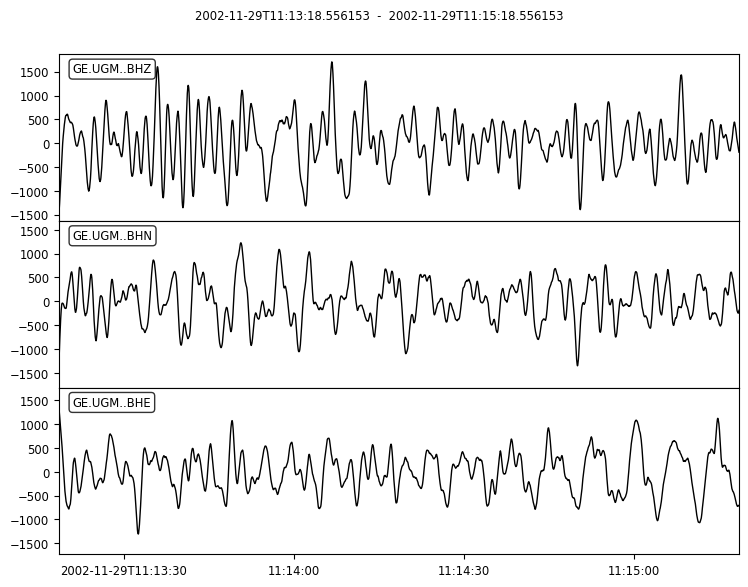

In [10]:
import pandas as pd
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import matplotlib.pyplot as plt

def plot_verification_sample():
    PATH_INVENTORY = r"D:\indonesia_output\MASTER_STATION_INVENTORY.csv"
    df = pd.read_csv(PATH_INVENTORY)
    
    # Ambil 1 sampel saja untuk pengecekan visual
    row = df.sample(n=1).iloc[0]
    client = Client("EARTHSCOPE" if row['Server'] == 'IRIS' else "GFZ")
    t_event = UTCDateTime(row['Time_UTC'])

    print(f"📈 Memvisualisasikan Waveform: {row['Event_ID']} pada stasiun {row['Station']}")
    
    try:
        # Ambil 120 detik (2 menit) agar terlihat gelombang P dan S-nya
        st = client.get_waveforms(row['Net'], row['Station'], "*", "BH*", t_event, t_event + 120)
        
        # Filter sederhana agar grafik terlihat cantik (Bandpass 0.1 - 10 Hz)
        st.filter('bandpass', freqmin=0.1, freqmax=10.0)
        
        # Plot 3 komponen sekaligus
        st.plot(size=(800, 600))
        
    except Exception as e:
        print(f"Gagal plot: {e}")

if __name__ == "__main__":
    plot_verification_sample()

In [33]:
import pandas as pd
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import winsound

# --- CONFIG ---
PATH_INVENTORY = r"D:\indonesia_output\MASTER_STATION_INVENTORY.csv"
ACADEMIC_ID = (
    "Researcher: Very Kurnia Bakti; PhD AI & Edge Computing; "
    "Contact: verykurniabakti@gmail.com; Scopus: 57209452703"
)

def verify_diverse_stations(n_samples=5):
    print(f"🔍 Memulai validasi silang untuk {n_samples} stasiun berbeda...")
    
    try:
        df = pd.read_csv(PATH_INVENTORY)
    except:
        print("❌ File MASTER_STATION_INVENTORY.csv tidak ditemukan.")
        return

    # Ambil daftar stasiun unik yang tersedia saat ini
    unique_stations = df['Station'].unique()
    
    # Pilih 5 stasiun secara acak (atau sebanyak yang tersedia jika < 5)
    selected_stations = pd.Series(unique_stations).sample(n=min(n_samples, len(unique_stations))).tolist()
    
    clients = {
        "IRIS": Client("EARTHSCOPE", user_agent=ACADEMIC_ID, timeout=50),
        "GFZ": Client("GFZ", user_agent=ACADEMIC_ID, timeout=50)
    }

    results = []

    for sta in selected_stations:
        # Ambil satu contoh kejadian untuk stasiun ini
        sample_row = df[df['Station'] == sta].iloc[0]
        
        print(f"\n--- Checking Station: {sta} | Server: {sample_row['Server']} ---")
        t = UTCDateTime(sample_row['Time_UTC'])
        cl = clients.get(sample_row['Server'])
        
        try:
            # Request waveform pendek (30 detik) untuk verifikasi komponen
            st = cl.get_waveforms(sample_row['Net'], sta, "*", "BH*", t, t + 30)
            
            # Ekstrak komponen unik (Z, N, E / 1, 2)
            comps = sorted(list(set([tr.stats.channel[-1] for tr in st])))
            
            # Cek kelengkapan
            valid = {'Z'}.issubset(comps) and ({'N', 'E'}.issubset(comps) or {'1', '2'}.issubset(comps))
            
            status = "✅ LENGKAP (3-CH)" if valid else "❌ DATA TIDAK LENGKAP"
            print(f"📡 Components Found: {comps} -> {status}")
            
            if valid: winsound.Beep(1200, 200)
            results.append((sta, status))
            
        except Exception as e:
            print(f"⚠️ Gagal mengunduh {sta}: {e}")
            results.append((sta, "❌ ERROR/TIMEOUT"))

    print("\n" + "="*40)
    print("📋 SUMMARY VALIDASI LINTAS STASIUN")
    print("="*40)
    for s, st in results:
        print(f"Station {s.ljust(6)} : {st}")

if __name__ == "__main__":
    verify_diverse_stations(5)

🔍 Memulai validasi silang untuk 5 stasiun berbeda...

--- Checking Station: UGM | Server: IRIS ---
📡 Components Found: ['E', 'N', 'Z'] -> ✅ LENGKAP (3-CH)

--- Checking Station: BKB | Server: GFZ ---
⚠️ Gagal mengunduh BKB: No data available for request.
HTTP Status code: 204
Detailed response of server:



--- Checking Station: BOAB | Server: IRIS ---
⚠️ Gagal mengunduh BOAB: No data available for request.
HTTP Status code: 204
Detailed response of server:



--- Checking Station: KAPI | Server: IRIS ---
📡 Components Found: ['E', 'N', 'Z'] -> ✅ LENGKAP (3-CH)

📋 SUMMARY VALIDASI LINTAS STASIUN
Station UGM    : ✅ LENGKAP (3-CH)
Station BKB    : ❌ ERROR/TIMEOUT
Station BOAB   : ❌ ERROR/TIMEOUT
Station KAPI   : ✅ LENGKAP (3-CH)


In [39]:
import pandas as pd
df = pd.read_csv(r"D:\indonesia_output\MASTER_STATION_INVENTORY.csv")
print(df['Station'].value_counts())

Station
BOAB    11748
UGM      7833
KAPI     3918
BKB       301
Name: count, dtype: int64
